Iter:   0 | Obj: 1191087.4554 | Change: 0.200
Iter:  10 | Obj: 62217.2057 | Change: 0.200
Iter:  20 | Obj: 44651.3672 | Change: 0.200
Iter:  30 | Obj: 39389.5607 | Change: 0.200
Iter:  40 | Obj: 38092.3385 | Change: 0.165
Iter:  50 | Obj: 37662.5056 | Change: 0.119
Iter:  59 | Obj: 37345.8144 | Change: 0.097


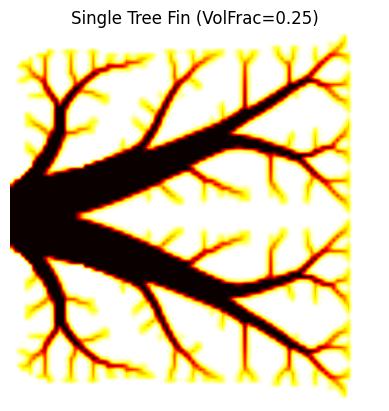

In [10]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

def single_tree_optimization(nelx=100, nely=100, volfrac=0.25, penal=3.0, rmin=1.25):
    # Setup
    ndof = (nelx + 1) * (nely + 1)
    x = volfrac * np.ones(nely * nelx)
    max_iter = 60

    # Local conductivity matrix for a 4-node quad element
    k_l = np.array([[ 2/3, -1/6, -1/3, -1/6],
                    [-1/6,  2/3, -1/6, -1/3],
                    [-1/3, -1/6,  2/3, -1/6],
                    [-1/6, -1/3, -1/6,  2/3]])

    # Map elements to degrees of freedom
    nodenrs = np.arange(ndof).reshape((nelx + 1, nely + 1)).T
    edofMat = np.zeros((nelx * nely, 4), dtype=int)
    for elx in range(nelx):
        for ely in range(nely):
            el = elx * nely + ely
            n1, n2 = nodenrs[ely, elx], nodenrs[ely, elx+1]
            n3, n4 = nodenrs[ely+1, elx+1], nodenrs[ely+1, elx]
            edofMat[el, :] = [n1, n2, n3, n4]

    iK = np.kron(edofMat, np.ones((4, 1))).flatten()
    jK = np.kron(edofMat, np.ones((1, 4))).flatten()

    # --- MODIFICATION: SINGLE POINT SINK ---
    # We fix the temperature to 0 at the center of the left edge (the root)
    root_node = nodenrs[nely // 2, 0]
    fixed_nodes = np.array([root_node])
    free_nodes = np.setdiff1d(np.arange(ndof), fixed_nodes)

    # Distributed thermal load (heat generated everywhere)
    F = 0.01 * np.ones((ndof, 1))

    # Optimization loop
    for loop in range(max_iter):
        # Assemble global matrix
        sK = ((0.001 + x**penal) * k_l.flatten()[:, np.newaxis]).flatten(order='F')
        K = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsr()

        # Solve Heat Equation
        T = np.zeros(ndof)
        T[free_nodes] = spsolve(K[free_nodes, :][:, free_nodes], F[free_nodes])

        # Sensitivity Analysis (Compliance)
        ce = np.sum((T[edofMat] @ k_l) * T[edofMat], axis=1)
        obj = np.sum((0.001 + x**penal) * ce)
        dc = -penal * x**(penal - 1) * ce

        # Filtering
        dc = mesh_filter(nelx, nely, rmin, x, dc)

        # Optimality Criteria Update
        x_old = x.copy()
        x = optimality_criteria(nelx, nely, x, volfrac, dc)

        change = np.linalg.norm(x - x_old, np.inf)
        if loop % 10 == 0 or loop == max_iter - 1:
            print(f"Iter: {loop:3d} | Obj: {obj:.4f} | Change: {change:.3f}")

    # Final Visualization
    plt.imshow(x.reshape((nely, nelx), order='F'), cmap='hot_r', interpolation='bilinear')
    plt.title(f"Single Tree Fin (VolFrac={volfrac})")
    plt.axis('off')
    plt.show()

def mesh_filter(nelx, nely, rmin, x, dc):
    # Simplified vectorized-style filter logic for clarity
    dcf = np.zeros_like(dc)
    for i in range(nelx):
        for j in range(nely):
            sum_w = 0.0
            idx = i * nely + j
            imin, imax = max(0, i-int(rmin)), min(nelx, i+int(rmin)+1)
            jmin, jmax = max(0, j-int(rmin)), min(nely, j+int(rmin)+1)
            for k in range(imin, imax):
                for l in range(jmin, jmax):
                    fac = rmin - np.sqrt((i-k)**2 + (j-l)**2)
                    if fac > 0:
                        sum_w += fac
                        dcf[idx] += fac * x[k*nely + l] * dc[k*nely + l]
            dcf[idx] /= (max(1e-3, x[idx]) * sum_w)
    return dcf

def optimality_criteria(nelx, nely, x, volfrac, dc):
    l1, l2, move = 0, 1e5, 0.2
    while (l2 - l1) > 1e-4:
        lmid = 0.5 * (l1 + l2)
        x_new = np.clip(x * np.sqrt(-dc / lmid), np.maximum(0, x - move), np.minimum(1, x + move))
        if np.mean(x_new) > volfrac: l1 = lmid
        else: l2 = lmid
    return x_new

if __name__ == "__main__":
    single_tree_optimization()

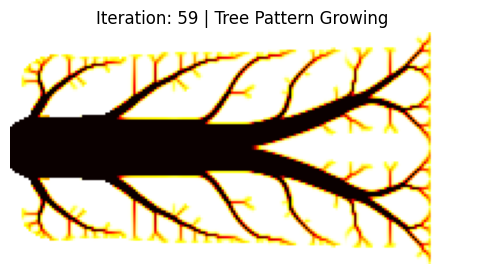

In [4]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from IPython import display
import time

def colab_tree_optimization(nelx=150, nely=100, volfrac=0.25, penal=3.0, rmin=1.25):
    # 1. Setup Parameters
    ndof = (nelx + 1) * (nely + 1)
    x = volfrac * np.ones(nely * nelx)

    # Local conductivity matrix
    k_l = np.array([[2/3,-1/6,-1/3,-1/6],[-1/6,2/3,-1/6,-1/3],[-1/3,-1/6,2/3,-1/6],[-1/6,-1/3,-1/6,2/3]])

    # Map elements to DOFs
    nodenrs = np.arange(ndof).reshape((nelx + 1, nely + 1)).T
    edofMat = np.zeros((nelx * nely, 4), dtype=int)
    for elx in range(nelx):
        for ely in range(nely):
            el = elx * nely + ely
            edofMat[el, :] = [nodenrs[ely, elx], nodenrs[ely, elx+1],
                             nodenrs[ely+1, elx+1], nodenrs[ely+1, elx]]

    iK = np.kron(edofMat, np.ones((4, 1))).flatten()
    jK = np.kron(edofMat, np.ones((1, 4))).flatten()

    # BC: Single root heat sink at middle-left
    fixed_nodes = np.array([nodenrs[nely // 2, 0]])
    free_nodes = np.setdiff1d(np.arange(ndof), fixed_nodes)
    F = 0.01 * np.ones((ndof, 1))

    # 2. Optimization Loop
    for loop in range(60):
        # Assemble & Solve
        sK = ((0.001 + x**penal) * k_l.flatten()[:, np.newaxis]).flatten(order='F')
        K = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsr()
        T = np.zeros(ndof)
        T[free_nodes] = spsolve(K[free_nodes, :][:, free_nodes], F[free_nodes])

        # Sensitivities & Filtering
        ce = np.sum((T[edofMat] @ k_l) * T[edofMat], axis=1)
        dc = -penal * x**(penal - 1) * ce

        # Simple Filter
        dcf = np.zeros_like(dc)
        for i in range(nelx):
            for j in range(nely):
                idx, sum_w = i * nely + j, 0.0
                for k in range(max(0, i-int(rmin)), min(nelx, i+int(rmin)+1)):
                    for l in range(max(0, j-int(rmin)), min(nely, j+int(rmin)+1)):
                        fac = rmin - np.sqrt((i-k)**2 + (j-l)**2)
                        if fac > 0:
                            sum_w += fac
                            dcf[idx] += fac * x[k*nely + l] * dc[k*nely + l]
                dcf[idx] /= (max(1e-3, x[idx]) * sum_w)

        # Density Update (OC)
        l1, l2 = 0, 1e5
        while (l2 - l1) > 1e-4:
            lmid = 0.5 * (l1 + l2)
            x_new = np.clip(x * np.sqrt(-dcf / lmid), np.maximum(0, x - 0.2), np.minimum(1, x + 0.2))
            if np.mean(x_new) > volfrac: l1 = lmid
            else: l2 = lmid
        x = x_new

        # 3. Colab Animation Logic
        display.clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(x.reshape((nely, nelx), order='F'), cmap='hot_r')
        plt.title(f"Iteration: {loop} | Tree Pattern Growing")
        plt.axis('off')
        plt.show()
        time.sleep(0.0000005) # Control the speed of growth

colab_tree_optimization()

In [9]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
import matplotlib.animation as animation
from IPython.display import HTML

def save_tree_optimization_mp4(nelx=150, nely=100, volfrac=0.35, penal=2.0, rmin=1.2, filename="fin_optimization.mp4"):
    ndof = (nelx + 1) * (nely + 1)
    x = volfrac * np.ones(nely * nelx)

    # Local conductivity matrix
    k_l = np.array([[2/3,-1/6,-1/3,-1/6],[-1/6,2/3,-1/6,-1/3],[-1/3,-1/6,2/3,-1/6],[-1/6,-1/3,-1/6,2/3]])

    # Map elements to DOFs
    nodenrs = np.arange(ndof).reshape((nelx + 1, nely + 1)).T
    edofMat = np.zeros((nelx * nely, 4), dtype=int)
    for elx in range(nelx):
        for ely in range(nely):
            el = elx * nely + ely
            edofMat[el, :] = [nodenrs[ely, elx], nodenrs[ely, elx+1],
                             nodenrs[ely+1, elx+1], nodenrs[ely+1, elx]]

    iK = np.kron(edofMat, np.ones((4, 1))).flatten()
    jK = np.kron(edofMat, np.ones((1, 4))).flatten()

    fixed_nodes = np.array([nodenrs[nely // 2, 0]])
    free_nodes = np.setdiff1d(np.arange(ndof), fixed_nodes)
    F = 0.01 * np.ones((ndof, 1))

    # Setup for Animation
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.axis('off')
    frames = [] # To store images for the video

    print("Optimizing and generating frames...")

    for loop in range(60):
        # FEA Solve
        sK = ((0.001 + x**penal) * k_l.flatten()[:, np.newaxis]).flatten(order='F')
        K = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsr()
        T = np.zeros(ndof)
        T[free_nodes] = spsolve(K[free_nodes, :][:, free_nodes], F[free_nodes])

        # Sensitivities
        ce = np.sum((T[edofMat] @ k_l) * T[edofMat], axis=1)
        dc = -penal * x**(penal - 1) * ce

        # Simple Filter
        dcf = np.zeros_like(dc)
        for i in range(nelx):
            for j in range(nely):
                idx, sum_w = i * nely + j, 0.0
                for k in range(max(0, i-int(rmin)), min(nelx, i+int(rmin)+1)):
                    for l in range(max(0, j-int(rmin)), min(nely, j+int(rmin)+1)):
                        fac = rmin - np.sqrt((i-k)**2 + (j-l)**2)
                        if fac > 0:
                            sum_w += fac
                            dcf[idx] += fac * x[k*nely + l] * dc[k*nely + l]
                dcf[idx] /= (max(1e-3, x[idx]) * sum_w)

        # Density Update
        l1, l2 = 0, 1e5
        while (l2 - l1) > 1e-4:
            lmid = 0.5 * (l1 + l2)
            x_new = np.clip(x * np.sqrt(-dcf / lmid), np.maximum(0, x - 0.2), np.minimum(1, x + 0.2))
            if np.mean(x_new) > volfrac: l1 = lmid
            else: l2 = lmid
        x = x_new

        # Append frame
        img = ax.imshow(x.reshape((nely, nelx), order='F'), cmap='hot_r', animated=True)
        if loop == 0:
            ax.imshow(x.reshape((nely, nelx), order='F'), cmap='hot_r') # Initial plot
        frames.append([img])

    # 3. Create Animation and Save
    print("Encoding video...")
    ani = animation.ArtistAnimation(fig, frames, interval=50, blit=True, repeat_delay=1000)

    # Save command
    writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
    ani.save(filename, writer=writer)

    plt.close()
    print(f"Success! File saved as {filename}")
    return ani

# Run and Display
ani = save_tree_optimization_mp4()
HTML(ani.to_html5_video())

Optimizing and generating frames...
Encoding video...
Success! File saved as fin_optimization.mp4


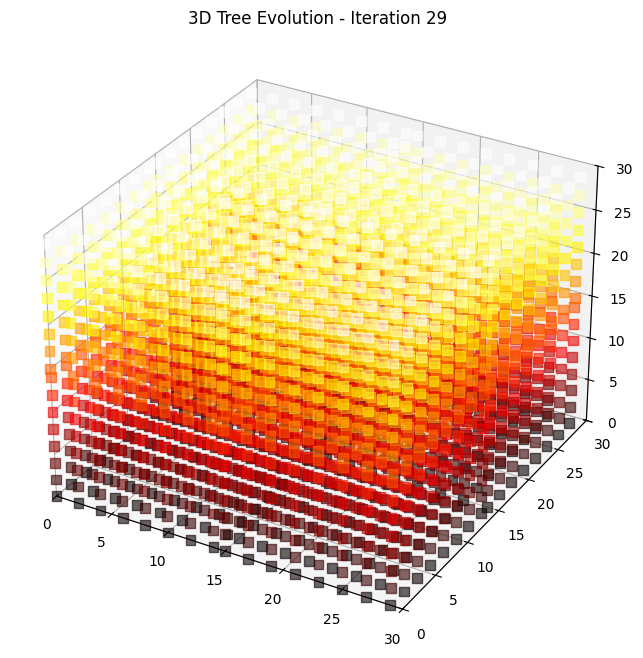

In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display

def topo_3d_tree(nelx=30, nely=30, nelz=30, volfrac=0.15, penal=3.0, rmin=1.2):
    # Parameters
    max_iter = 30
    ndof = (nelx + 1) * (nely + 1) * (nelz + 1)
    x = volfrac * np.ones(nelz * nely * nelx)

    # 3D Node Mapping
    nodes = np.arange(ndof).reshape((nelx + 1, nely + 1, nelz + 1))

    # Element DOF mapping (8 nodes per hex element)
    edofMat = np.zeros((nelx * nely * nelz, 8), dtype=int)
    for i in range(nelx):
        for j in range(nely):
            for k in range(nelz):
                el = i * nely * nelz + j * nelz + k
                n = nodes[i:i+2, j:j+2, k:k+2].flatten()
                edofMat[el, :] = n

    # Simplified 3D local conductivity (diagonal approximation for speed)
    k_l = np.eye(8) * (1/8)

    # BCs: Root point at the center of the bottom face (z=0)
    root_node = nodes[nelx // 2, nely // 2, 0]
    fixed_nodes = np.array([root_node])
    free_nodes = np.setdiff1d(np.arange(ndof), fixed_nodes)
    F = 0.01 * np.ones((ndof, 1))

    # Assembly indices
    iK = np.kron(edofMat, np.ones((8, 1))).flatten()
    jK = np.kron(edofMat, np.ones((1, 8))).flatten()

    for loop in range(max_iter):
        # FEA Solve
        sK = ((0.001 + x**penal) * k_l.flatten()[:, np.newaxis]).flatten(order='F')
        K = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsr()

        T = np.zeros(ndof)
        T[free_nodes] = spsolve(K[free_nodes, :][:, free_nodes], F[free_nodes])

        # Sensitivities (simplified for 3D demo)
        ce = np.sum((T[edofMat]**2), axis=1)
        dc = -penal * x**(penal - 1) * ce

        # OC Update
        l1, l2 = 0, 1e5
        while (l2 - l1) > 1e-4:
            lmid = 0.5 * (l1 + l2)
            x_new = np.clip(x * np.sqrt(-dc / lmid), np.maximum(0, x - 0.2), np.minimum(1, x + 0.2))
            if np.mean(x_new) > volfrac: l1 = lmid
            else: l2 = lmid
        x = x_new

        # --- 3D Visualization ---
        display.clear_output(wait=True)
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Only plot elements with high density (the "fin")
        vol = x.reshape((nelx, nely, nelz))
        z, y, x_coords = np.where(vol > 0.5)

        ax.scatter(x_coords, y, z, c=z, cmap='hot', marker='s', s=50, alpha=0.6)
        ax.set_title(f"3D Tree Evolution - Iteration {loop}")
        ax.set_xlim(0, nelx); ax.set_ylim(0, nely); ax.set_zlim(0, nelz)
        plt.show()

topo_3d_tree()